Note: Hypothesis Testing ek statistical tarika hai yeh check karne ka ki data mein dikh raha koi pattern "real" hai ya sirf random chance se aaya hai. Har test mein 2 competing statements hoti hain:

- Null Hypothesis (H₀): "Koi real difference/effect nahi hai" (status quo, boring assumption)

- Alternate Hypothesis (H₁): "Real difference/effect hai" (jo hum prove karna chahte hain)


1. Real business question se shuru karte hain: "Kya churned customers ka average Monetary spend, non-churned customers se significantly alag hai — ya yeh fark sirf random variation hai?"

In [1]:
import pandas as pd

df = pd.read_csv('../data/processed/customer_churn_labeled.csv')

churned_spend = df[df['Churned'] == 1]['Monetary']
not_churned_spend = df[df['Churned'] == 0]['Monetary']

print(f"Churned mean spend: {churned_spend.mean():.2f}")
print(f"Not-Churned mean spend: {not_churned_spend.mean():.2f}")

Churned mean spend: 1133.22
Not-Churned mean spend: 4834.09


2. Hypotheses likhna (yeh sabse important step hai, code se pehle):

In [2]:
print("""
H0 (Null Hypothesis): Churned aur Not-Churned customers ka average Monetary spend SAME hai
                       (jo fark dikh raha hai, woh sirf random chance hai)

H1 (Alternate Hypothesis): Churned aur Not-Churned customers ka average Monetary spend ALAG hai
                            (yeh fark real hai, random nahi)
""")


H0 (Null Hypothesis): Churned aur Not-Churned customers ka average Monetary spend SAME hai
                       (jo fark dikh raha hai, woh sirf random chance hai)

H1 (Alternate Hypothesis): Churned aur Not-Churned customers ka average Monetary spend ALAG hai
                            (yeh fark real hai, random nahi)



3. Sample sizes check karna (test choose karne se pehle zaroori):

In [3]:
print(f"Churned sample size: {len(churned_spend)}")
print(f"Not-Churned sample size: {len(not_churned_spend)}")

Churned sample size: 2987
Not-Churned sample size: 2894


4. Visual se pehle intuition banao (kal p-value se confirm karenge):

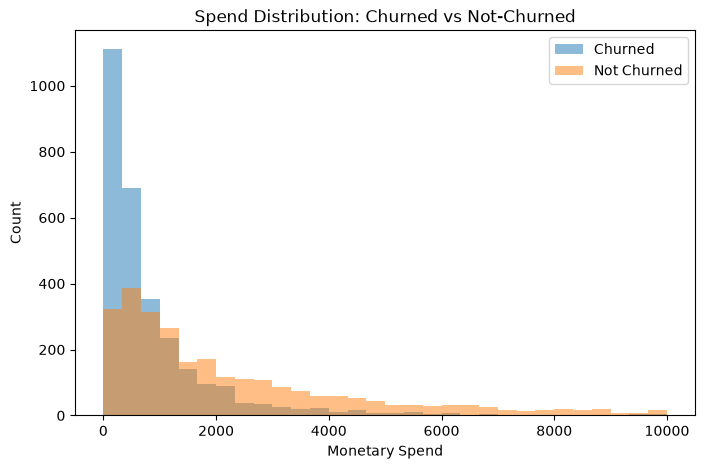

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(churned_spend, bins=30, alpha=0.5, label='Churned', range=(0, 10000))
plt.hist(not_churned_spend, bins=30, alpha=0.5, label='Not Churned', range=(0, 10000))
plt.xlabel('Monetary Spend')
plt.ylabel('Count')
plt.title('Spend Distribution: Churned vs Not-Churned')
plt.legend()
plt.show()

5. Ek chhota simulation se samajhna ki "chance se fark" kaisa dikhta hai (intuition-building exercise):

In [5]:
import numpy as np

# Agar hum RANDOMLY 2 groups banate (bina churn ka koi asar hue) to unka mean fark kitna hota?
np.random.seed(1)
random_group_diffs = []
for _ in range(100):
    shuffled = df['Monetary'].sample(frac=1).reset_index(drop=True)
    group_a = shuffled[:len(churned_spend)]
    group_b = shuffled[len(churned_spend):]
    random_group_diffs.append(group_a.mean() - group_b.mean())

print(f"Actual difference (Churned - Not Churned): {churned_spend.mean() - not_churned_spend.mean():.2f}")
print(f"Random shuffling differences range: {min(random_group_diffs):.2f} to {max(random_group_diffs):.2f}")
print(f"Random shuffling average difference: {np.mean(random_group_diffs):.2f}")

Actual difference (Churned - Not Churned): -3700.87
Random shuffling differences range: -944.93 to 983.71
Random shuffling average difference: 18.53


Note: Agar actual difference, random shuffling ke differences ke range se bahut bahar hai, to strong evidence hai ki fark real hai (churn status genuinely spend se related hai). Agar actual difference random differences ke range ke andar hi hai, to shayad fark chance se bhi ho sakta tha. Kal (Day 44) hum isko p-value se precisely quantify karenge, formal test se.

6. Key terms preview (kal detail mein aayenge):

In [6]:
print("""
Important terms for tomorrow:
- Significance level (alpha): usually 0.05 (5%) — yeh threshold hai "chance se fark" ko reject karne ka
- p-value: probability ki observed difference sirf chance se aaya (agar H0 true hoti)
- Decision rule: agar p-value < alpha, to H0 reject karo (matlab fark REAL hai)
                 agar p-value >= alpha, to H0 reject nahi kar sakte (fark chance se ho sakta hai)
""")


Important terms for tomorrow:
- Significance level (alpha): usually 0.05 (5%) — yeh threshold hai "chance se fark" ko reject karne ka
- p-value: probability ki observed difference sirf chance se aaya (agar H0 true hoti)
- Decision rule: agar p-value < alpha, to H0 reject karo (matlab fark REAL hai)
                 agar p-value >= alpha, to H0 reject nahi kar sakte (fark chance se ho sakta hai)



Practice questions:

1. Same exercise Frequency column ke liye karo — Churned vs Not-Churned ka average Frequency compare karo, aur apna khud ka H0/H1 likho.

- Hypothesis Definition:

    - H_0 (Null Hypothesis): Churned aur Not-Churned customers ki average Frequency SAME hai (jo bhi fark dikh raha hai, woh sirf random chance hai).

    - H_1 (Alternate Hypothesis): Churned aur Not-Churned customers ki average Frequency ALAG hai (yeh fark real hai, random nahi).

Churned mean frequency: 3.05
Not-Churned mean frequency: 9.63
Churned sample size: 2987
Not-Churned sample size: 2894


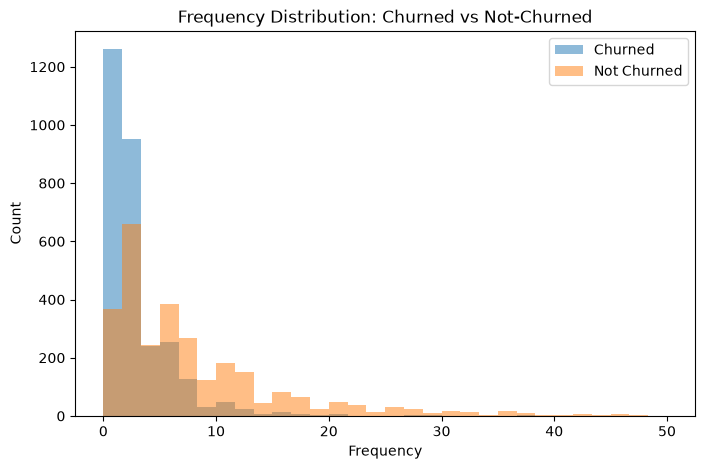

Actual difference (Churned - Not Churned) in Frequency: -6.58
Random shuffling differences range: -0.83 to 0.83
Random shuffling average difference: -0.02


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data load karna
df = pd.read_csv('../data/processed/customer_churn_labeled.csv')

# Groups banana
churned_freq = df[df['Churned'] == 1]['Frequency']
not_churned_freq = df[df['Churned'] == 0]['Frequency']

# 1. Means print karna
print(f"Churned mean frequency: {churned_freq.mean():.2f}")
print(f"Not-Churned mean frequency: {not_churned_freq.mean():.2f}")

# 2. Sample sizes check karna
print(f"Churned sample size: {len(churned_freq)}")
print(f"Not-Churned sample size: {len(not_churned_freq)}")

# 3. Visualization
plt.figure(figsize=(8, 5))
plt.hist(churned_freq, bins=30, alpha=0.5, label='Churned', range=(0, 50))
plt.hist(not_churned_freq, bins=30, alpha=0.5, label='Not Churned', range=(0, 50))
plt.xlabel('Frequency')
plt.ylabel('Count')
plt.title('Frequency Distribution: Churned vs Not-Churned')
plt.legend()
plt.show()

# 4. Simulation (Intuition check)
np.random.seed(1)
random_group_diffs_freq = []
for _ in range(100):
    shuffled = df['Frequency'].sample(frac=1).reset_index(drop=True)
    group_a = shuffled[:len(churned_freq)]
    group_b = shuffled[len(churned_freq):]
    random_group_diffs_freq.append(group_a.mean() - group_b.mean())

actual_diff = churned_freq.mean() - not_churned_freq.mean()
print(f"Actual difference (Churned - Not Churned) in Frequency: {actual_diff:.2f}")
print(f"Random shuffling differences range: {min(random_group_diffs_freq):.2f} to {max(random_group_diffs_freq):.2f}")
print(f"Random shuffling average difference: {np.mean(random_group_diffs_freq):.2f}")

2. Socho aur likho (comment mein): agar Recency ka fark churned vs not-churned mein bahut obvious hai (matlab churned customers ka Recency naturally zyada hoga kyunki wahi churn ki definition hai), to kya isko hypothesis test karna meaningful hai? Kyun ya kyun nahi?

Answer: Nahi, Recency par hypothesis test karna bilkul bhi meaningful nahi hai (aur yeh ek statistical redundancy hai).

Kyun nahi hai meaningful? (Reasoning):

- 1.Data Leakage / Circular Logic: Churn ka matlab hi aam taur par yeh hota hai ki customer ne kaafi time se purchase nahi kiya (yani unki Recency bahut high hogi). Agar definition mein hi yeh baat shamil hai ki jo customer kaafi din se inactive hai woh churned hai, toh statistical test karke yeh "saabit" karne ki zaroorat nahi hai ki unki Recency alag hai. Yeh pehle se hi tay (pre-determined) hai.


- 2.Obvious / Trivial Fact: Hypothesis testing tab ki jaati hai jab aapko doubt ho ki koi pattern real hai ya chance se hai. Jaha pattern 100% guaranteed aur obvious ho (jaise ki churned logo ki recency zyada honi hi honi hai), waha test chalana apna waqt barbad karne jaisa hai.


- 3.Data Science mein Rule: Statistical tests hamesha unpredictable relationships ya unknown insights ko discover karne ke liye use hote hain, un cheezon ke liye nahi jo business logic ki wajah se pehle se hi obvious hain.